# VLM Playground

Pick an image, pick a model, type a prompt, evaluate. Swap models freely.

In [8]:
import sys, os, base64, time, json

import httpx
from pathlib import Path
from IPython.display import display, Image as IPImage, Markdown
from dotenv import load_dotenv
load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")
print(f"OpenRouter key: {'set (' + OPENROUTER_API_KEY[:12] + '...)' if OPENROUTER_API_KEY else 'MISSING -- set in .env'}")

OpenRouter key: set (sk-or-v1-016...)


## 1. Models
Change `MODEL` to swap. All use OpenRouter.

In [9]:
MODELS = {
    # Free
    "gemma3-12b-free":     "google/gemma-3-12b-it:free",
    "gemma3-27b-free":     "google/gemma-3-27b-it:free",
    "nemotron-12b-free":   "nvidia/nemotron-nano-12b-v2-vl:free",
    "gemma3-4b-free":      "google/gemma-3-4b-it:free",
    # Cheap
    "qwen3-vl-8b":         "qwen/qwen3-vl-8b-instruct",
    "qwen3-vl-8b-think":   "qwen/qwen3-vl-8b-thinking",
    "qwen3-vl-32b":        "qwen/qwen3-vl-32b-instruct",
    "qwen3-vl-30b-a3b":    "qwen/qwen3-vl-30b-a3b-instruct",
    "llama-3.2-11b":       "meta-llama/llama-3.2-11b-vision-instruct",
    "ui-tars-7b":          "bytedance/ui-tars-1.5-7b",
    "mistral-small-24b":   "mistralai/mistral-small-3.1-24b-instruct",
    # Ceiling
    "gemini-2.5-flash":    "google/gemini-2.5-flash",
    "gpt-4o-mini":         "openai/gpt-4o-mini",
    "gpt-5.4-nano":        "openai/gpt-5.4-nano",
    "sonnet":              "anthropic/claude-sonnet-4.6",
}

print("Available models:")
for k, v in MODELS.items():
    print(f"  {k:25s} {v}")

Available models:
  gemma3-12b-free           google/gemma-3-12b-it:free
  gemma3-27b-free           google/gemma-3-27b-it:free
  nemotron-12b-free         nvidia/nemotron-nano-12b-v2-vl:free
  gemma3-4b-free            google/gemma-3-4b-it:free
  qwen3-vl-8b               qwen/qwen3-vl-8b-instruct
  qwen3-vl-8b-think         qwen/qwen3-vl-8b-thinking
  qwen3-vl-32b              qwen/qwen3-vl-32b-instruct
  qwen3-vl-30b-a3b          qwen/qwen3-vl-30b-a3b-instruct
  llama-3.2-11b             meta-llama/llama-3.2-11b-vision-instruct
  ui-tars-7b                bytedance/ui-tars-1.5-7b
  mistral-small-24b         mistralai/mistral-small-3.1-24b-instruct
  gemini-2.5-flash          google/gemini-2.5-flash
  gpt-4o-mini               openai/gpt-4o-mini
  gpt-5.4-nano              openai/gpt-5.4-nano
  sonnet                    anthropic/claude-sonnet-4.6


## 2. Pick Image
Point to a screenshot or load from the game server.

Upload a Catan board screenshot:


FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload')

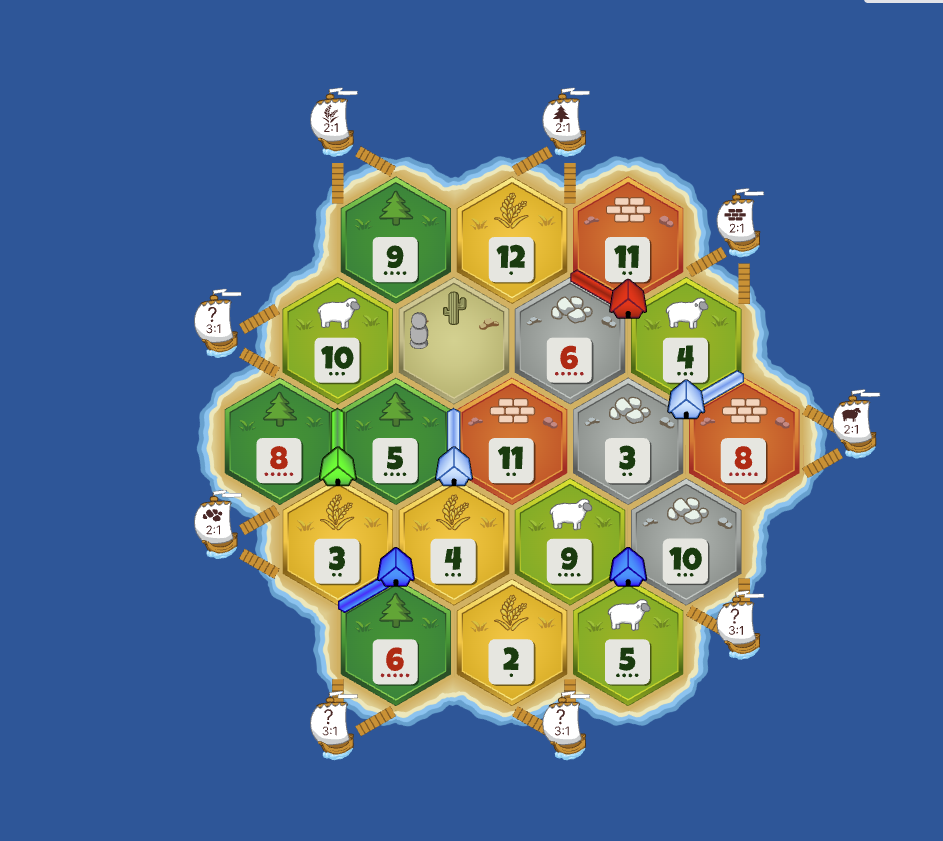

In [ ]:
import ipywidgets as widgets
from io import BytesIO

img_bytes = None
IMG_PATH = "uploaded"

uploader = widgets.FileUpload(accept=".png,.jpg,.jpeg", multiple=False)

def on_upload(change):
    global img_bytes, IMG_PATH
    uploaded = uploader.value
    if not uploaded:
        return
    # Handle both dict (older ipywidgets) and tuple (newer ipywidgets) formats
    if isinstance(uploaded, dict):
        name = list(uploaded.keys())[0]
        img_bytes = uploaded[name]["content"]
    elif isinstance(uploaded, tuple):
        entry = uploaded[0]
        name = entry.get("name", "upload.png") if isinstance(entry, dict) else entry.name
        img_bytes = entry.get("content", b"") if isinstance(entry, dict) else entry.content.tobytes()
    else:
        print(f"Unexpected upload format: {type(uploaded)}")
        return
    IMG_PATH = name
    print(f"Loaded: {name} ({len(img_bytes) / 1024:.0f} KB)")
    display(IPImage(data=img_bytes, width=500))

uploader.observe(on_upload, names="value")
print("Upload a Catan board screenshot:")
display(uploader)

## 3. Query Function

In [12]:
def query(model_key: str, prompt: str, system_prompt: str = "",
          temperature: float = 0.2, max_tokens: int = 4096) -> dict:
    """Send image + prompt to an OpenRouter model. Returns full result dict."""
    model_id = MODELS[model_key]
    b64 = base64.b64encode(img_bytes).decode("utf-8")

    # Free/Gemma models don't support system prompts
    no_system = "free" in model_id or "gemma" in model_id.lower()

    messages = []
    if system_prompt and not no_system:
        messages.append({"role": "system", "content": system_prompt})

    user_text = prompt
    if system_prompt and no_system:
        user_text = f"{system_prompt}\n\n---\n\n{prompt}"

    messages.append({
        "role": "user",
        "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
            {"type": "text", "text": user_text},
        ],
    })

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://github.com/catan-learning",
        "X-Title": "Catan VLM Playground",
    }
    payload = {
        "model": model_id,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }

    start = time.time()
    resp = httpx.post("https://openrouter.ai/api/v1/chat/completions",
                      headers=headers, json=payload, timeout=120.0)
    latency_ms = int((time.time() - start) * 1000)

    if resp.status_code >= 400:
        return {"error": f"HTTP {resp.status_code}: {resp.text[:500]}", "latency_ms": latency_ms}

    data = resp.json()
    content = data["choices"][0]["message"].get("content") or ""
    reasoning = data["choices"][0]["message"].get("reasoning_content") or ""
    if reasoning and content:
        content = f"<thinking>\n{reasoning}\n</thinking>\n\n{content}"
    elif reasoning:
        content = reasoning

    return {
        "content": content,
        "latency_ms": latency_ms,
        "model": data.get("model", model_id),
        "usage": data.get("usage", {}),
    }

print("query() ready.")

query() ready.


## 4. Prompt & Evaluate

Change `MODEL`, `SYSTEM_PROMPT`, and `PROMPT` below, then re-run this cell.
That's the whole workflow -- tweak and re-run.

In [21]:
# ============================================================
# CHANGE THESE THREE THINGS
# ============================================================

MODEL = "qwen3-vl-32b"  # <-- swap this to try different models

SYSTEM_PROMPT = """You are a visual analyzer for a Settlers of Catan board game screenshot.

Rules:
- ONLY describe what you can literally see in the image.
- If you cannot read a number or color clearly, say "unclear" instead of guessing.
- Do not use any prior knowledge about Catan boards to fill in gaps.
- Do not describe what a Catan board "typically" looks like.
- Be specific: use exact numbers, exact colors, exact positions.
- Light Green is sheep with the sheep Icon
- Dark Green is wood with the tree Icon
- Red is brick with the brick Icon
- Yellow is wheat with the wheat Icon
- Gray is ore with the ore Icon
- If you are unsure about something, skip it entirely."""

PROMPT = """What is the current state of the game?"""

# ============================================================
# RUN
# ============================================================

print(f"Model: {MODEL} ({MODELS[MODEL]})")
print(f"Prompt: {PROMPT[:80]}...\n")

result = query(MODEL, PROMPT, system_prompt=SYSTEM_PROMPT)

if "error" in result:
    print(f"ERROR: {result['error']}")
else:
    print(f"Latency: {result['latency_ms']}ms | Model: {result['model']}")
    if result.get('usage'):
        u = result['usage']
        print(f"Tokens: {u.get('prompt_tokens', '?')} in / {u.get('completion_tokens', '?')} out")
    print(f"{'='*60}\n")
    display(Markdown(result['content']))

Model: qwen3-vl-32b (qwen/qwen3-vl-32b-instruct)
Prompt: What is the current state of the game?...

Latency: 11100ms | Model: qwen/qwen3-vl-32b-instruct
Tokens: 933 in / 697 out



The image shows a Settlers of Catan board in a specific configuration, but it does not provide information about the current state of the game (e.g., player scores, resources held, turn order, or number of players). Therefore, based only on what is visible in the image:

- The board consists of 19 hexagonal terrain tiles arranged in a hexagonal pattern.
- Each hex has a number token (2–12) and a resource type:
  - **Light Green (sheep)**: hexes with numbers 10, 4, 9, 9, 5 (5 total)
  - **Dark Green (wood)**: hexes with numbers 9, 8, 5, 6 (4 total)
  - **Yellow (wheat)**: hexes with numbers 12, 3, 4, 2 (4 total)
  - **Red (brick)**: hexes with numbers 11, 8, 11 (3 total)
  - **Gray (ore)**: hexes with numbers 6, 3, 10 (3 total)
- There is one **desert** hex (no number, with a cactus and robber icon) located in the center.
- The **robber** is placed on the gray ore hex with number 6.
- There are **settlements** (small houses) placed on the following hex corners:
  - One **red** settlement on the ore hex with number 6.
  - One **blue** settlement on the ore hex with number 3.
  - One **blue** settlement on the wheat hex with number 4.
  - One **blue** settlement on the sheep hex with number 9.
  - One **blue** settlement on the sheep hex with number 5.
  - One **green** settlement on the wood hex with number 8.
- There are **cities** (large houses) placed on the following hex corners:
  - One **blue** city on the wheat hex with number 3.
  - One **blue** city on the wood hex with number 6.
- There are **ports** around the edge of the board:
  - Two **3:1** ports (unclear which resource, marked with a question mark) at the top-left and bottom-left.
  - Two **3:1** ports (unclear which resource, marked with a question mark) at the bottom-right and top-right.
  - One **2:1** port for **sheep** (with sheep icon) at the top-left.
  - One **2:1** port for **wood** (with tree icon) at the top-center.
  - One **2:1** port for **brick** (with brick icon) at the top-right.
  - One **2:1** port for **wheat** (with wheat icon) at the right-center.
  - One **2:1** port for **ore** (with ore icon) at the bottom-right.

No player resource cards, development cards, or victory point totals are visible.

**Conclusion**: The image shows a static board setup with settlements, cities, and the robber placed. However, without information on player resources, turn status, or scores, the current state of the game cannot be determined beyond the board configuration.

## 5. Quick Compare

Run the same prompt across multiple models side-by-side.

In [ ]:
from concurrent.futures import ThreadPoolExecutor

COMPARE_MODELS = [
    "qwen3-vl-32b",
    "gemma3-12b-free",
    "qwen3-vl-8b",
    # "gemini-2.5-flash",  # uncomment for ceiling test
]

# Uses same SYSTEM_PROMPT and PROMPT from above
compare_results = {}

with ThreadPoolExecutor(max_workers=len(COMPARE_MODELS)) as pool:
    futures = {k: pool.submit(query, k, PROMPT, SYSTEM_PROMPT) for k in COMPARE_MODELS}
    for k in COMPARE_MODELS:
        compare_results[k] = futures[k].result(timeout=180)

for k, r in compare_results.items():
    print(f"{'='*60}")
    if "error" in r:
        print(f"{k}: ERROR -- {r['error']}\n")
        continue
    print(f"{k} ({r['model']}) -- {r['latency_ms']}ms")
    print(f"{'='*60}")
    display(Markdown(r['content'][:2000]))
    print()

## 6. History

Every query is appended here so you can review past runs.

In [ ]:
# Auto-append results to history
if 'history' not in dir():
    history = []

if 'result' in dir() and result and 'error' not in result:
    history.append({
        "model": MODEL,
        "prompt": PROMPT[:100],
        "latency_ms": result['latency_ms'],
        "response_preview": result['content'][:200],
    })

print(f"{len(history)} queries in history:\n")
for i, h in enumerate(history):
    print(f"  {i+1}. {h['model']:25s} {h['latency_ms']:>6d}ms  {h['prompt'][:50]}...")

## 7. Save Results

In [ ]:
output_path = "data_pipeline/training/pretraining/output/vlm_playground_results.json"
Path(output_path).parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump({
        "image": IMG_PATH,
        "history": history,
        "compare": {k: {
            "model": r.get("model", k),
            "latency_ms": r.get("latency_ms"),
            "content": r.get("content", "")[:3000],
        } for k, r in compare_results.items()} if 'compare_results' in dir() else {},
    }, f, indent=2, default=str)

print(f"Saved to {output_path}")